<a href="https://colab.research.google.com/github/sionide/CMPE-131-HW3/blob/main/Iris_ClassDemo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Jason

SJSU ID: 018304273

GitHub link: https://github.com/sionide

In [ ]:
# Basic python libraries - numeric calculations, dataframes, and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The dataset for this activity
from sklearn.datasets import load_iris

# The ML libraries
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

# ML Methodology
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
iris   = load_iris()
X_iris = iris.data
y_iris = iris.target

In [ ]:
X_iris.shape

(150, 4)

iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

TODO: Explore the shapes of X_iris and y_iris

In [ ]:
# Put it in a dataframe
df_iris = pd.DataFrame(X_iris, columns=iris.feature_names)
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
# Adds another column
df_iris['species'] = [iris.target_names[t] for t in y_iris]

In [ ]:
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Pick any two features and plot them against each other

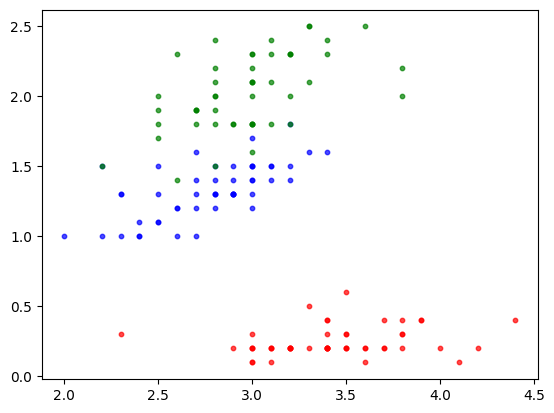

In [ ]:
features = iris.feature_names
colors   = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}

feat1 = features[1]
feat2 = features[3]

for species, color in colors.items():
  mask = df_iris['species'] == species
  plt.scatter(df_iris.loc[mask, feat1],
              df_iris.loc[mask, feat2],
              c=color, s=10, alpha=0.7)

The textbook full plot is below:

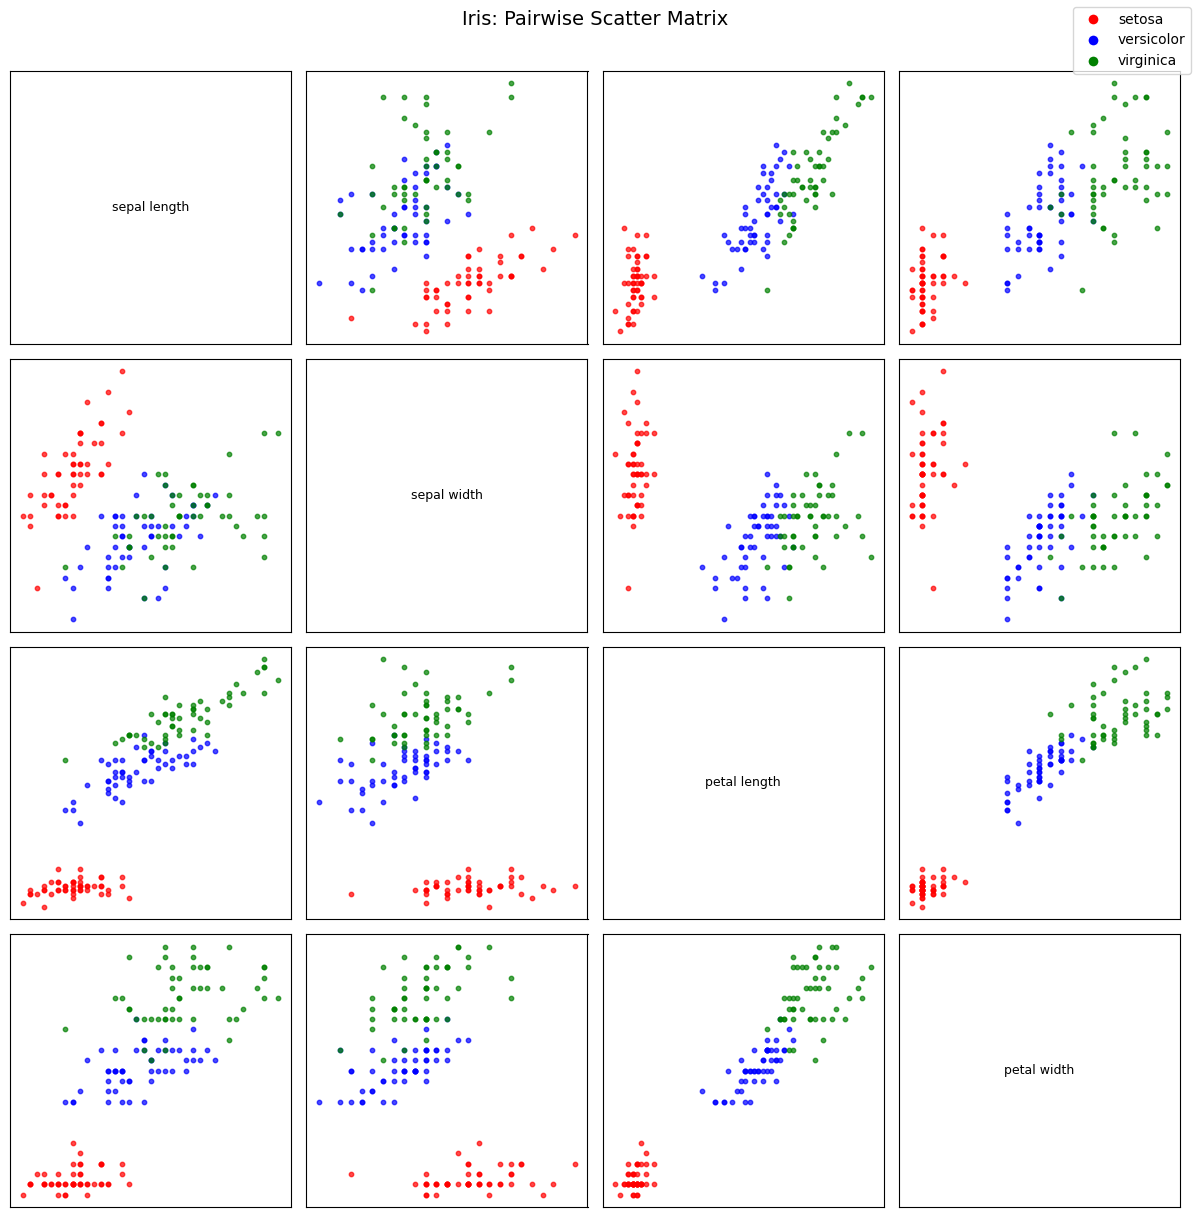

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i, feat_i in enumerate(features):
    for j, feat_j in enumerate(features):
        ax = axes[i][j]
        if i == j:
            ax.text(0.5, 0.5, feat_i.replace(' (cm)', ''),
                    ha='center', va='center', fontsize=9, wrap=True)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            for species, color in colors.items():
                mask = df_iris['species'] == species
                ax.scatter(df_iris.loc[mask, feat_j],
                           df_iris.loc[mask, feat_i],
                           c=color, s=10, alpha=0.7)
            ax.set_xticks([])
            ax.set_yticks([])

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=c, markersize=8, label=s)
           for s, c in colors.items()]
fig.legend(handles=handles, loc='upper right', fontsize=10)
fig.suptitle('Iris: Pairwise Scatter Matrix', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Let's do Machine Learning on this data now

Difference between *Supervised*, *Unsupervised*, and *Self-supervised* learning

### Supervised learning

In supervised learning, the known species labels (y_iris) are provided during training. For example, logistic regression learns a mapping from the four flower measurements to setosa, versicolor, or virginica. We then evaluate predictions on held-out flowers using accuracy or classification error. The left plot above shows the labeled data used to define this prediction task.

### Unsupervised learning

K-Means is unsupervised here because it receives only X_iris, not y_iris. It groups flowers by measurement similarity and returns cluster IDs, cluster ID 0 is not inherently “setosa.” The known species labels are used only afterward to interpret the result with the adjusted Rand index.

### Self-supervised learning

Self-supervised learning creates targets from the data itself. One simple Iris example is to hide one measurement (for example, petal width) and train a model to reconstruct it from the other three measurements. The original petal width acts as the target, so no human species labels are needed. The learned representation could later be used for classification or clustering. This is different from unsupervised clustering because it defines a specific pretext prediction task.

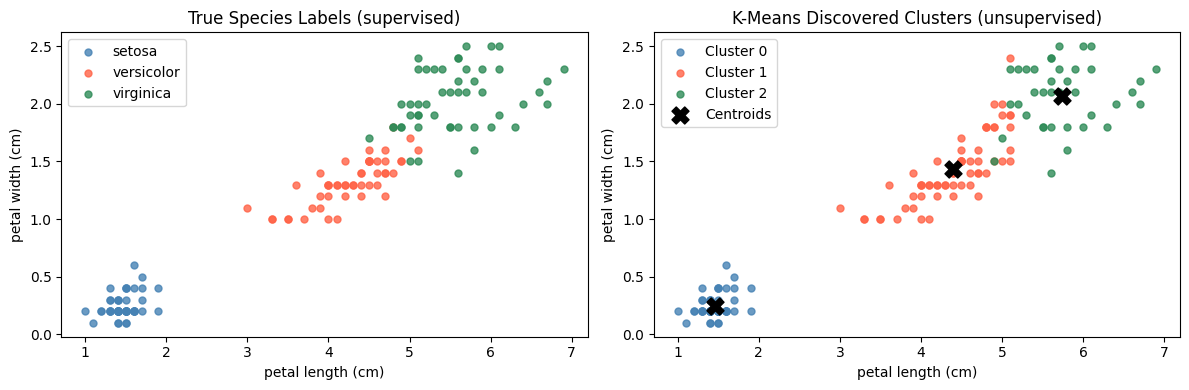

In [ ]:
# K-Means on Iris — no labels used during fitting
kmeans = KMeans(n_clusters=3, n_init=10)
cluster_labels = kmeans.fit_predict(X_iris)

# Visualize on petal length vs. petal width (the most separable pair)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: true species labels
for species, color, idx in zip(iris.target_names,
                                ['steelblue', 'tomato', 'seagreen'],
                                [0, 1, 2]):
    mask = y_iris == idx
    axes[0].scatter(X_iris[mask, 2], X_iris[mask, 3],
                    c=color, s=25, alpha=0.8, label=species)
axes[0].set_xlabel('petal length (cm)')
axes[0].set_ylabel('petal width (cm)')
axes[0].set_title('True Species Labels (supervised)')
axes[0].legend()

# Right: k-means clusters (no labels used)
cluster_colors = ['steelblue', 'tomato', 'seagreen']
for k in range(3):
    mask = cluster_labels == k
    axes[1].scatter(X_iris[mask, 2], X_iris[mask, 3],
                    c=cluster_colors[k], s=25, alpha=0.8, label=f'Cluster {k}')
axes[1].scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3],
                c='black', marker='X', s=150, zorder=5, label='Centroids')
axes[1].set_xlabel('petal length (cm)')
axes[1].set_ylabel('petal width (cm)')
axes[1].set_title('K-Means Discovered Clusters (unsupervised)')
axes[1].legend()

plt.tight_layout()
plt.show()

Generalization

In [ ]:
# Train/test split for Iris — 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2
)

# Fit logistic regression
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

iris_lr_ein  = 1 - accuracy_score(y_train, clf.predict(X_train))
iris_lr_eout = 1 - accuracy_score(y_test,  clf.predict(X_test))

print(f'Logistic Regression on Iris:')
print(f'  E_in  (120 training samples) = {iris_lr_ein:.3f}')
print(f'  E_out  (30 test samples)     = {iris_lr_eout:.3f}')
print(f'  Generalization gap            = {iris_lr_eout - iris_lr_ein:.3f}')

Logistic Regression on Iris:
  E_in  (120 training samples) = 0.033
  E_out  (30 test samples)     = 0.033
  Generalization gap            = 0.000


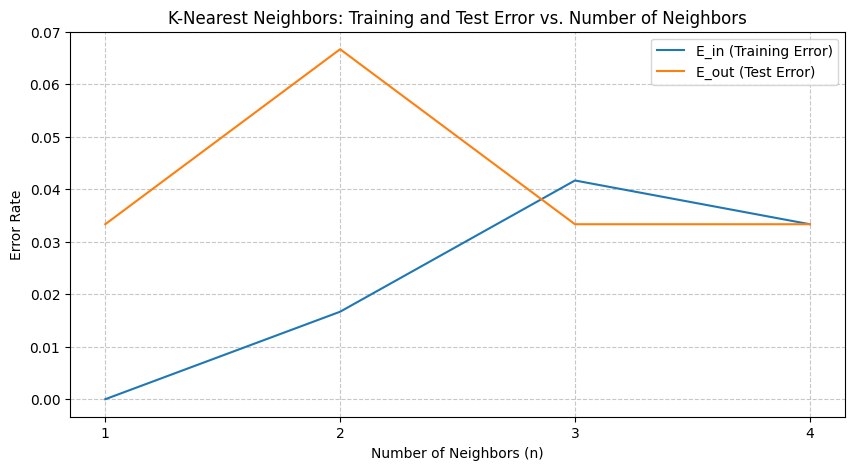

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

ns = range(1, 5)
eins = []
eouts = []

for n in ns:
  clf = KNeighborsClassifier(n_neighbors=n)
  clf.fit(X_train, y_train)

  ein  = 1 - accuracy_score(y_train, clf.predict(X_train))
  eout = 1 - accuracy_score(y_test,  clf.predict(X_test))
  eins.append(ein)
  eouts.append(eout)

plt.figure(figsize=(10, 5))
plt.plot(ns, eins, label='E_in (Training Error)')
plt.plot(ns, eouts, label='E_out (Test Error)')
plt.xlabel('Number of Neighbors (n)')
plt.ylabel('Error Rate')
plt.title('K-Nearest Neighbors: Training and Test Error vs. Number of Neighbors')
plt.xticks(ns)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()